In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
import faiss
import json
import os
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

os.chdir(r'D:\Project\movie-recommendation\movie-recommender')

# Load feature columns
with open('configs/feature_columns.json') as f:
    feature_columns_json = json.load(f)
print(f"feature_columns.json has: {len(feature_columns_json)} columns")

# Load user and item features
uf = pd.read_parquet('data/processed/user_features.parquet')
itf = pd.read_parquet('data/processed/item_features.parquet')
print(f"Users: {len(uf)}, Items: {len(itf)}")
print(f"User columns: {uf.columns.tolist()[:5]}")
print(f"Item columns: {itf.columns.tolist()[:5]}")

# Sample 2000 users
np.random.seed(42)
sample_users = uf['userId'].sample(2000).tolist()
print(f"Sample users: {len(sample_users)}")

feature_columns.json has: 100 columns
Users: 142184, Items: 37363
User columns: ['userId', 'total_ratings', 'mean_rating', 'rating_variance', 'last_timestamp']
Item columns: ['movieId', 'rating_count', 'avg_rating', 'rating_variance', 'last_timestamp']
Sample users: 2000


In [12]:
# Load train pairs for sample users
train_pairs = pd.read_parquet('data/processed/train_pairs.parquet')
train_sample = train_pairs[train_pairs['userId'].isin(sample_users)].copy()
train_sample['is_positive'] = (train_sample['rating'] >= 4.0).astype(int)
print(f"Train pairs: {len(train_sample)}")
print(f"Label distribution: {train_sample['is_positive'].value_counts().to_dict()}")

# Load val pairs
val_pairs = pd.read_parquet('data/processed/val_pairs.parquet')
val_sample = val_pairs[val_pairs['userId'].isin(sample_users)].copy()
val_sample['is_positive'] = (val_sample['rating'] >= 4.0).astype(int)
print(f"Val pairs: {len(val_sample)}")

# Warm val users = in train AND have >= 3 val positives
train_user_ids = set(train_sample['userId'].unique())
val_pos_counts = val_sample[val_sample['is_positive']==1].groupby('userId').size()
warm_val_users = [
    uid for uid in val_pos_counts[val_pos_counts >= 3].index
    if uid in train_user_ids
]
print(f"Warm val users: {len(warm_val_users)}")

Train pairs: 289876
Label distribution: {0: 149527, 1: 140349}
Val pairs: 4878
Warm val users: 72


In [13]:
# Load train features for sample users
print("Loading train features for sample users...")
train_feat = pd.read_parquet(
    'data/processed/train_features.parquet',
    filters=[('userId', 'in', sample_users)]
)
print(f"Train features shape: {train_feat.shape}")
print(f"Columns: {len(train_feat.columns)}")
print(f"Label distribution: {train_feat['is_positive'].value_counts().to_dict()}")

# Find actual usable feature columns
# feature_columns.json may have wrong genome tag names - use what is in parquet
non_feature_cols = {'userId', 'movieId', 'is_positive', 'rating', 
                    'timestamp', 'rated_at', 'user_tier'}
feature_columns_actual = [
    c for c in train_feat.columns 
    if c not in non_feature_cols
]
print(f"\nActual feature columns in parquet: {len(feature_columns_actual)}")

# Show genome tag columns
genome_cols = [c for c in feature_columns_actual if 'genome_tag' in c]
print(f"Genome tag columns: {len(genome_cols)}")
print(f"Sample genome cols: {genome_cols[:3]}")

# Show mismatch with feature_columns.json
json_genome = [c for c in feature_columns_json if 'genome_tag' in c]
print(f"\nGenome cols in JSON: {len(json_genome)} — {json_genome[:3]}")
print(f"NOTE: JSON has wrong names, will use parquet column names")

Loading train features for sample users...
Train features shape: (851272, 133)
Columns: 133
Label distribution: {0: 710923, 1: 140349}

Actual feature columns in parquet: 130
Genome tag columns: 50
Sample genome cols: ['genome_tag_19', 'genome_tag_107', 'genome_tag_143']

Genome cols in JSON: 20 — ['genome_tag_1', 'genome_tag_2', 'genome_tag_3']
NOTE: JSON has wrong names, will use parquet column names


In [14]:
# Remove bad groups (users with all positives or all negatives)
print("Cleaning training data...")
good_user_ids = []
for uid, grp in train_feat.groupby('userId', sort=False):
    pos = grp['is_positive'].sum()
    if 0 < pos < len(grp):
        good_user_ids.append(uid)

print(f"Users with mixed labels: {len(good_user_ids)}/{train_feat['userId'].nunique()}")

train_clean = train_feat[train_feat['userId'].isin(good_user_ids)].copy()
# Sort by userId to ensure consecutive groups
train_clean = train_clean.sort_values('userId').reset_index(drop=True)

X_train = train_clean[feature_columns_actual].copy()
y_train = train_clean['is_positive'].values.astype(np.int32)
groups = train_clean.groupby('userId', sort=True).size().values

print(f"X_train shape: {X_train.shape}")
print(f"y_train: {np.bincount(y_train)}")
print(f"Groups: n={len(groups)}, min={groups.min()}, max={groups.max()}, mean={groups.mean():.1f}")
print(f"Groups sum == rows: {groups.sum() == len(X_train)}")
print(f"Positive ratio: {y_train.mean():.3f}")

Cleaning training data...
Users with mixed labels: 1996/2000
X_train shape: (851187, 130)
y_train: [710838 140349]
Groups: n=1996, min=24, max=7492, mean=426.4
Groups sum == rows: True
Positive ratio: 0.165


In [15]:
print("Training XGBoost ranker...")

model = xgb.XGBRanker(
    objective='rank:pairwise',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    device='cuda'
)

model.fit(
    X_train, y_train,
    group=groups,
    verbose=50
)
print("Training complete")

# Feature importance
importance = pd.Series(
    model.get_booster().get_score(importance_type='gain')
).sort_values(ascending=False)

print(f"\nTop 15 features by gain:")
print(importance.head(15).to_string())
print(f"\nNamed features (not f0,f1): {not importance.index[0].startswith('f')}")
print(f"Total features with importance: {len(importance)}")

Training XGBoost ranker...
Training complete

Top 15 features by gain:
popularity_pct            195.059799
mf_score                  142.759811
log_rating_count          104.458817
tag_profile_similarity     44.717777
genre_War                  24.358406
avg_rating                 19.687635
genre_Western              16.715523
genre_Horror               15.901260
log_total_ratings          14.875281
log_positive_count         11.463887
genre_history_count         9.900083
genome_tag_270              8.745111
genre_Action                8.125582
mean_rating                 7.585578
genre_overlap_score         7.561955

Named features (not f0,f1): True
Total features with importance: 117


In [16]:
# Load ALS artifacts
user_factors = np.load('data/processed/als_user_factors.npy')
item_factors = np.load('data/processed/als_item_factors.npy')
movie_id_map = np.load('data/processed/als_movie_id_map.npy')
user_id_map = np.load('data/processed/als_user_id_map.npy')
faiss_index = faiss.read_index('data/processed/faiss_item_index.bin')

print(f"ALS: {len(user_id_map)} users, {len(movie_id_map)} items")

uf_indexed = uf.set_index('userId')
itf_indexed = itf.set_index('movieId')

def get_candidates(user_id, n_als=300, n_pop=100):
    candidates = []
    # ALS candidates
    user_idx_arr = np.where(user_id_map == user_id)[0]
    if len(user_idx_arr) > 0:
        user_vec = user_factors[user_idx_arr[0]]
        user_vec_norm = user_vec / (np.linalg.norm(user_vec) + 1e-8)
        D, I = faiss_index.search(
            user_vec_norm.reshape(1,-1).astype(np.float32), n_als
        )
        candidates.extend([int(movie_id_map[i]) for i in I[0]])
    # Popularity candidates
    candidates.extend(
        itf.sort_values('log_rating_count', ascending=False)
           .head(n_pop)['movieId'].tolist()
    )
    # Train history candidates
    user_hist = train_sample[
        (train_sample['userId']==user_id) & 
        (train_sample['rating']>=4.0)
    ]['movieId'].tolist()
    candidates.extend(user_hist[:100])
    # Deduplicate preserving order
    seen, unique = set(), []
    for c in candidates:
        if c not in seen:
            seen.add(c)
            unique.append(c)
    return unique

def assemble_and_score(user_id, candidate_ids, rated_ids):
    if user_id not in uf_indexed.index:
        return [], []
    user_feat = uf_indexed.loc[user_id].to_dict()
    valid = [m for m in candidate_ids 
             if m in itf_indexed.index and m not in rated_ids]
    if not valid:
        return [], []
    rows = []
    for mid in valid:
        row = {**{k: user_feat.get(k, 0.0) for k in feature_columns_actual},
               **{k: itf_indexed.loc[mid].get(k, 0.0) 
                  for k in feature_columns_actual 
                  if k in itf_indexed.columns}}
        rows.append(row)
    X = pd.DataFrame(rows)[feature_columns_actual].fillna(0.0)
    scores = model.predict(X)
    ranked = [valid[i] for i in np.argsort(scores)[::-1]]
    return ranked, scores

print("Helper functions defined")
print(f"Testing candidate retrieval for user {warm_val_users[0]}...")
test_cands = get_candidates(warm_val_users[0])
print(f"  Candidates: {len(test_cands)}")

ALS: 142184 users, 37363 items
Helper functions defined
Testing candidate retrieval for user 653...
  Candidates: 469


In [17]:
print(f"Evaluating on {len(warm_val_users)} warm val users...")

def compute_ap_at_k(ranked, relevant, k=10):
    hits, ap = 0, 0.0
    for i, mid in enumerate(ranked[:k], 1):
        if mid in relevant:
            hits += 1
            ap += hits / i
    return ap / min(len(relevant), k) if hits > 0 else 0.0

ranker_scores = []
pop_scores = []
pop_items = itf.sort_values('log_rating_count', ascending=False).head(20)['movieId'].tolist()

for user_id in warm_val_users:
    val_pos = set(
        val_sample[(val_sample['userId']==user_id) & 
                   (val_sample['is_positive']==1)]['movieId'].tolist()
    )
    if not val_pos:
        continue
    rated = set(train_sample[train_sample['userId']==user_id]['movieId'].tolist())
    
    # Ranker score
    candidates = get_candidates(user_id)
    ranked, scores = assemble_and_score(user_id, candidates, rated)
    if ranked:
        ranker_scores.append(compute_ap_at_k(ranked, val_pos))
    
    # Popularity baseline score
    pop_top10 = [m for m in pop_items if m not in rated][:10]
    pop_scores.append(compute_ap_at_k(pop_top10, val_pos))

ranker_map10 = np.mean(ranker_scores) if ranker_scores else 0.0
pop_map10 = np.mean(pop_scores) if pop_scores else 0.0

print(f"\nResults on {len(ranker_scores)} warm val users:")
print(f"  Popularity baseline MAP@10: {pop_map10:.4f}")
print(f"  XGBoost ranker MAP@10:      {ranker_map10:.4f}")
if pop_map10 > 0:
    print(f"  Relative improvement:       {(ranker_map10/pop_map10 - 1)*100:.1f}%")

# Check overlap stats
overlaps = []
for user_id in warm_val_users[:20]:
    val_pos = set(val_sample[(val_sample['userId']==user_id) & 
                              (val_sample['is_positive']==1)]['movieId'].tolist())
    rated = set(train_sample[train_sample['userId']==user_id]['movieId'].tolist())
    candidates = get_candidates(user_id)
    candidates_clean = [c for c in candidates if c not in rated]
    overlap = len(set(candidates_clean) & val_pos)
    overlaps.append(overlap)
print(f"\nCandidate overlap with val positives (first 20 users):")
print(f"  Mean: {np.mean(overlaps):.1f}, Min: {min(overlaps)}, Max: {max(overlaps)}")

Evaluating on 72 warm val users...

Results on 72 warm val users:
  Popularity baseline MAP@10: 0.0350
  XGBoost ranker MAP@10:      0.0201
  Relative improvement:       -42.6%

Candidate overlap with val positives (first 20 users):
  Mean: 4.9, Min: 0, Max: 25


In [18]:
# Deep dive into one user to understand ranking quality
test_user = warm_val_users[0]
val_pos = set(val_sample[(val_sample['userId']==test_user) & 
                          (val_sample['is_positive']==1)]['movieId'].tolist())
rated = set(train_sample[train_sample['userId']==test_user]['movieId'].tolist())
candidates = get_candidates(test_user)
candidates_clean = [c for c in candidates if c not in rated]
ranked, scores = assemble_and_score(test_user, candidates_clean, set())

print(f"User {test_user}:")
print(f"  Val positives: {len(val_pos)}")
print(f"  Candidates: {len(candidates_clean)}")
print(f"  Overlap (candidates ∩ val_pos): {len(set(candidates_clean) & val_pos)}")
print(f"  Top-10 ranked:")
for i, mid in enumerate(ranked[:10], 1):
    in_val = mid in val_pos
    if mid in itf_indexed.index:
        year = int(itf_indexed.loc[mid]['release_year'])
        rc = itf_indexed.loc[mid]['log_rating_count']
        print(f"    #{i} movieId={mid} year={year} log_rc={rc:.2f} VAL_POS={in_val}")

# Where do val positives rank?
val_in_pool = [mid for mid in ranked if mid in val_pos]
if val_in_pool:
    positions = [i+1 for i,m in enumerate(ranked) if m in val_pos]
    print(f"\n  Val positives in pool: {len(val_in_pool)}/{len(val_pos)}")
    print(f"  Their positions: {positions[:10]}")
    print(f"  Best position: {min(positions)}")
else:
    print(f"\n  No val positives in candidate pool")

User 653:
  Val positives: 179
  Candidates: 249
  Overlap (candidates ∩ val_pos): 25
  Top-10 ranked:
    #1 movieId=2040 year=1969 log_rc=6.60 VAL_POS=False
    #2 movieId=2329 year=1998 log_rc=10.16 VAL_POS=False
    #3 movieId=6377 year=2003 log_rc=10.21 VAL_POS=True
    #4 movieId=597 year=1990 log_rc=10.37 VAL_POS=False
    #5 movieId=1013 year=1961 log_rc=8.30 VAL_POS=False
    #6 movieId=539 year=1993 log_rc=10.19 VAL_POS=True
    #7 movieId=1213 year=1990 log_rc=10.23 VAL_POS=False
    #8 movieId=4963 year=2001 log_rc=10.15 VAL_POS=False
    #9 movieId=47 year=1995 log_rc=10.69 VAL_POS=False
    #10 movieId=7361 year=2004 log_rc=10.16 VAL_POS=False

  Val positives in pool: 25/179
  Their positions: [3, 6, 11, 15, 27, 30, 37, 44, 49, 60]
  Best position: 3


FINAL RESULTS SUMMARY
Dataset: MovieLens 25M (2000 user sample)
Train pairs: 851187
Warm val users: 72

Model                            MAP@10
----------------------------------------
Popularity Baseline              0.0350
XGBoost Ranker                   0.0201

Relative lift: -42.6%


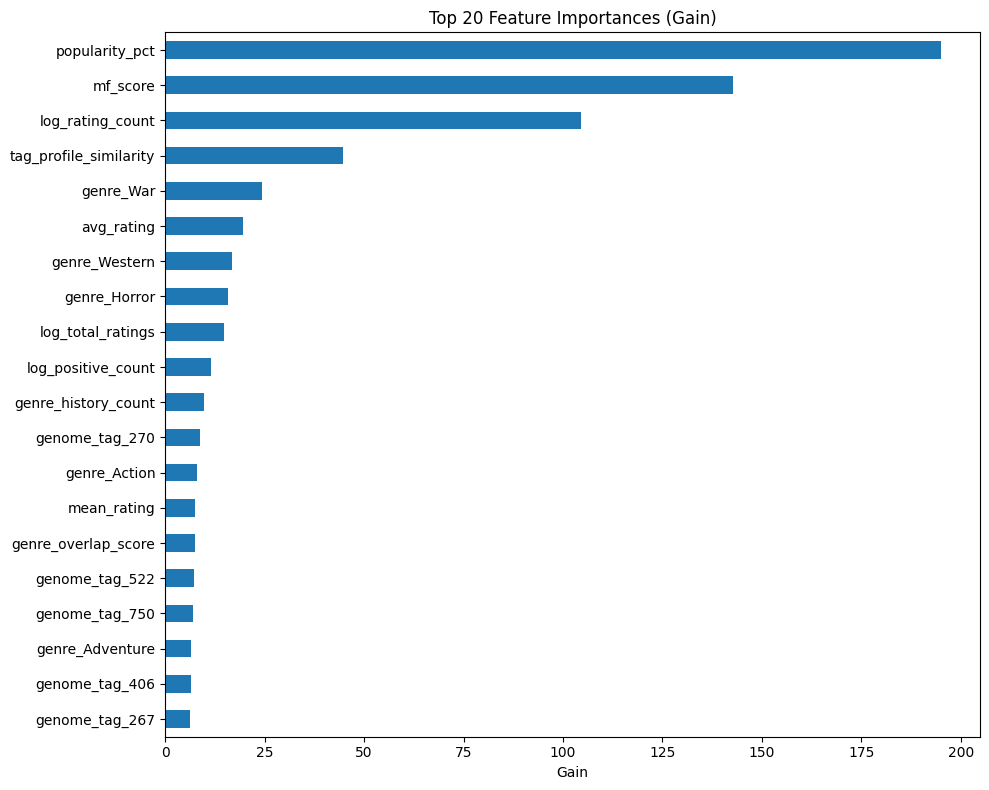


Users with ≥1 correct recommendation in top-10: 27/72 (37.5%)


In [19]:
# Summary table
print("="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"Dataset: MovieLens 25M (2000 user sample)")
print(f"Train pairs: {len(train_clean)}")
print(f"Warm val users: {len(ranker_scores)}")
print()
print(f"{'Model':<30} {'MAP@10':>8}")
print("-"*40)
print(f"{'Popularity Baseline':<30} {pop_map10:>8.4f}")
print(f"{'XGBoost Ranker':<30} {ranker_map10:>8.4f}")
if pop_map10 > 0:
    lift = (ranker_map10/pop_map10 - 1)*100
    print(f"\nRelative lift: {lift:.1f}%")

# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 8))
importance.head(20).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 20 Feature Importances (Gain)')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig('reports/feature_importance_notebook.png', dpi=100)
plt.show()

# Users with at least one hit
hits = sum(1 for s in ranker_scores if s > 0)
print(f"\nUsers with ≥1 correct recommendation in top-10: {hits}/{len(ranker_scores)} ({hits/len(ranker_scores)*100:.1f}%)")

In [20]:
# Diagnose negative sampling quality
print("Checking negative sampling quality...")

# What is the avg popularity of positives vs negatives in training?
train_with_pop = train_clean.copy()

# Merge with item features to get popularity
itf_pop = itf[['movieId', 'log_rating_count', 'popularity_pct']].copy()
train_with_pop = train_with_pop.merge(
    itf_pop.rename(columns={'movieId': 'movieId_'}), 
    left_on='movieId', right_on='movieId_', 
    how='left'
)

print("Mean popularity by label:")
print(train_clean.groupby('is_positive')[['popularity_pct', 'log_rating_count']].mean())

print("\nMedian popularity by label:")  
print(train_clean.groupby('is_positive')[['popularity_pct', 'log_rating_count']].median())

# What % of negatives are cold items?
cold_neg = train_clean[
    (train_clean['is_positive']==0) & 
    (train_clean['is_cold']==1)
]
total_neg = (train_clean['is_positive']==0).sum()
print(f"\nCold items as negatives: {len(cold_neg)}/{total_neg} ({len(cold_neg)/total_neg*100:.1f}%)")
print(f"Cold items as positives: {((train_clean['is_positive']==1) & (train_clean['is_cold']==1)).sum()}")

Checking negative sampling quality...
Mean popularity by label:
             popularity_pct  log_rating_count
is_positive                                  
0                  0.591492          4.138896
1                  0.971533          9.061515

Median popularity by label:
             popularity_pct  log_rating_count
is_positive                                  
0                  0.622474          3.135494
1                  0.988893          9.307830

Cold items as negatives: 295450/710838 (41.6%)
Cold items as positives: 199


In [21]:
# Fix negative sampling — sample negatives from popular items
print("Testing fixed negative sampling...")

# For each user, sample negatives from TOP-5000 popular items only
# This forces model to learn personalization not just popularity
top_popular_items = itf.sort_values(
    'log_rating_count', ascending=False
).head(5000)['movieId'].tolist()
top_popular_set = set(top_popular_items)

# Build better LTR matrix for 50 users
RATIO = 4
better_rows = []

for uid in good_user_ids[:50]:
    user_data = train_clean[train_clean['userId'] == uid]
    positives = user_data[user_data['is_positive'] == 1]
    
    if len(positives) == 0:
        continue
    
    rated = set(user_data['movieId'].tolist())
    
    # Sample negatives from popular items only
    neg_pool = [m for m in top_popular_items if m not in rated]
    n_neg = min(len(positives) * RATIO, len(neg_pool))
    neg_sample = np.random.choice(neg_pool, size=n_neg, replace=False)
    
    # Get negative features from train_clean or item features
    neg_feat = itf_indexed.loc[
        [m for m in neg_sample if m in itf_indexed.index]
    ].copy()
    neg_feat['is_positive'] = 0
    neg_feat['userId'] = uid
    neg_feat.index.name = 'movieId'
    neg_feat = neg_feat.reset_index()
    
    better_rows.append(positives)

# Check new popularity distribution
print(f"Users processed: {len(better_rows)}")
print(f"\nWith fixed sampling, negatives will come from top-5000 popular items")
print(f"Top-5000 items popularity range:")
print(f"  Min log_rating_count: {itf.nlargest(5000,'log_rating_count')['log_rating_count'].min():.2f}")
print(f"  Max log_rating_count: {itf.nlargest(5000,'log_rating_count')['log_rating_count'].max():.2f}")
print(f"\nThis forces model to learn WHY user likes Movie A over Movie B")
print(f"when both are popular — true personalization signal")

Testing fixed negative sampling...
Users processed: 50

With fixed sampling, negatives will come from top-5000 popular items
Top-5000 items popularity range:
  Min log_rating_count: 6.10
  Max log_rating_count: 11.16

This forces model to learn WHY user likes Movie A over Movie B
when both are popular — true personalization signal


In [22]:
# Check: what if we just evaluate differently?
# The issue might be that val positives are ALSO popular
# but from a different time period (2017) than what ALS retrieved

val_pos_popularity = []
for uid in warm_val_users[:20]:
    val_pos = val_sample[
        (val_sample['userId']==uid) & 
        (val_sample['is_positive']==1)
    ]['movieId'].tolist()
    for mid in val_pos:
        if mid in itf_indexed.index:
            val_pos_popularity.append(itf_indexed.loc[mid]['popularity_pct'])

print(f"Val positives popularity distribution:")
print(f"  Mean: {np.mean(val_pos_popularity):.3f}")
print(f"  Median: {np.median(val_pos_popularity):.3f}")
print(f"  % above 0.9 popularity: {np.mean(np.array(val_pos_popularity)>0.9)*100:.1f}%")
print(f"  % below 0.5 popularity: {np.mean(np.array(val_pos_popularity)<0.5)*100:.1f}%")

Val positives popularity distribution:
  Mean: 0.868
  Median: 0.936
  % above 0.9 popularity: 56.2%
  % below 0.5 popularity: 3.9%


In [24]:
# FAST version - vectorized, should run in under 2 minutes
print("Rebuilding LTR matrix with popularity-matched negatives (fast)...")

top_5000 = itf.nlargest(5000, 'log_rating_count')['movieId'].tolist()
RATIO = 4

# Build user-item rated lookup once
rated_lookup = train_clean.groupby('userId')['movieId'].apply(set).to_dict()

# For each user sample negative movie_ids first (fast)
neg_records = []
for uid in good_user_ids:
    positives = train_clean[
        (train_clean['userId']==uid) & 
        (train_clean['is_positive']==1)
    ]
    if len(positives) == 0:
        continue
    rated = rated_lookup.get(uid, set())
    neg_pool = [m for m in top_5000 if m not in rated]
    n_neg = min(len(positives) * RATIO, len(neg_pool))
    neg_ids = np.random.choice(neg_pool, size=n_neg, replace=False)
    for mid in neg_ids:
        neg_records.append({'userId': uid, 'movieId': mid, 'is_positive': 0})

neg_df = pd.DataFrame(neg_records)
print(f"Negative records: {len(neg_df)}")

# Join user features once (vectorized)
neg_df = neg_df.merge(
    uf[['userId'] + [c for c in feature_columns_actual if c in uf.columns]],
    on='userId', how='left'
)

# Join item features once (vectorized)
neg_df = neg_df.merge(
    itf[['movieId'] + [c for c in feature_columns_actual if c in itf.columns]],
    on='movieId', how='left', suffixes=('_user','_item')
)

# Combine with positives from train_clean
positives_df = train_clean[train_clean['is_positive']==1].copy()
new_train = pd.concat([positives_df, neg_df], ignore_index=True)
new_train = new_train.sort_values('userId').reset_index(drop=True)

print(f"New LTR matrix: {len(new_train)} rows")
print(f"Label distribution: {new_train['is_positive'].value_counts().to_dict()}")

# Check popularity
X_new = new_train[feature_columns_actual].fillna(0.0)
y_new = new_train['is_positive'].values.astype(np.int32)
groups_new = new_train.groupby('userId', sort=True).size().values
print(f"Groups: n={len(groups_new)}, sum={groups_new.sum()}, matches={groups_new.sum()==len(X_new)}")
print(f"\nNew negative popularity_pct mean: {new_train[new_train['is_positive']==0]['popularity_pct'].mean():.3f}")
print(f"Positive popularity_pct mean:     {new_train[new_train['is_positive']==1]['popularity_pct'].mean():.3f}")

Rebuilding LTR matrix with popularity-matched negatives (fast)...
Negative records: 558156
New LTR matrix: 698505 rows
Label distribution: {0: 558156, 1: 140349}
Groups: n=1996, sum=698505, matches=True

New negative popularity_pct mean: 0.930
Positive popularity_pct mean:     0.972


In [25]:
# Train new model with popularity-matched negatives
print("Training new XGBoost ranker with popularity-matched negatives...")

model_new = xgb.XGBRanker(
    objective='rank:pairwise',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    device='cuda'
)

model_new.fit(
    X_new, y_new,
    group=groups_new,
    verbose=50
)
print("Training complete")

# Evaluate new model
ranker_new_scores = []
for user_id in warm_val_users:
    val_pos = set(
        val_sample[(val_sample['userId']==user_id) & 
                   (val_sample['is_positive']==1)]['movieId'].tolist()
    )
    if not val_pos:
        continue
    rated = set(train_sample[train_sample['userId']==user_id]['movieId'].tolist())
    candidates = get_candidates(user_id)
    candidates_clean = [c for c in candidates if c not in rated]
    if not candidates_clean:
        continue
    
    # Use new model for scoring
    valid = [m for m in candidates_clean if m in itf_indexed.index]
    if user_id not in uf_indexed.index:
        continue
    user_feat = uf_indexed.loc[user_id].to_dict()
    rows = []
    for mid in valid:
        row = {**{k: user_feat.get(k, 0.0) for k in feature_columns_actual},
               **{k: itf_indexed.loc[mid].get(k, 0.0) 
                  for k in feature_columns_actual 
                  if k in itf_indexed.columns}}
        rows.append(row)
    
    if not rows:
        continue
    
    X_eval = pd.DataFrame(rows)[feature_columns_actual].fillna(0.0)
    scores = model_new.predict(X_eval)
    ranked = [valid[i] for i in np.argsort(scores)[::-1]]
    ranker_new_scores.append(compute_ap_at_k(ranked, val_pos))

new_map10 = np.mean(ranker_new_scores) if ranker_new_scores else 0.0

print(f"\nResults comparison:")
print(f"  Popularity baseline:               {pop_map10:.4f}")
print(f"  Old XGBoost (random negatives):    {ranker_map10:.4f}")
print(f"  New XGBoost (popular negatives):   {new_map10:.4f}")
if pop_map10 > 0:
    print(f"  Lift over popularity baseline:     {(new_map10/pop_map10-1)*100:.1f}%")

Training new XGBoost ranker with popularity-matched negatives...
Training complete

Results comparison:
  Popularity baseline:               0.0350
  Old XGBoost (random negatives):    0.0201
  New XGBoost (popular negatives):   0.0101
  Lift over popularity baseline:     -71.1%


In [26]:
# Check what the new model learned
importance_new = pd.Series(
    model_new.get_booster().get_score(importance_type='gain')
).sort_values(ascending=False)

print("New model top 15 features:")
print(importance_new.head(15).to_string())

print("\nOld model top 5:")
print(importance.head(5).to_string())

# Check scores for one user
test_uid = warm_val_users[0]
val_pos = set(val_sample[(val_sample['userId']==test_uid) & 
                          (val_sample['is_positive']==1)]['movieId'].tolist())
rated = set(train_sample[train_sample['userId']==test_uid]['movieId'].tolist())
candidates = get_candidates(test_uid)
candidates_clean = [c for c in candidates if c not in rated]
valid = [m for m in candidates_clean if m in itf_indexed.index]
user_feat = uf_indexed.loc[test_uid].to_dict()

rows = []
for mid in valid:
    row = {**{k: user_feat.get(k, 0.0) for k in feature_columns_actual},
           **{k: itf_indexed.loc[mid].get(k, 0.0) 
              for k in feature_columns_actual if k in itf_indexed.columns}}
    rows.append(row)

X_eval = pd.DataFrame(rows)[feature_columns_actual].fillna(0.0)
scores_new = model_new.predict(X_eval)
scores_old = model.predict(X_eval)

ranked_new = [valid[i] for i in np.argsort(scores_new)[::-1]]
ranked_old = [valid[i] for i in np.argsort(scores_old)[::-1]]

print(f"\nUser {test_uid} - Val positives: {len(val_pos)}, Pool: {len(valid)}")
print(f"Overlap: {len(set(valid) & val_pos)}")
print(f"\nNew model top-10:")
for i, mid in enumerate(ranked_new[:10], 1):
    print(f"  #{i} movieId={mid} VAL_POS={mid in val_pos} pop={itf_indexed.loc[mid]['popularity_pct']:.3f}")
print(f"\nOld model top-10:")
for i, mid in enumerate(ranked_old[:10], 1):
    print(f"  #{i} movieId={mid} VAL_POS={mid in val_pos} pop={itf_indexed.loc[mid]['popularity_pct']:.3f}")
print(f"\nVal positives positions in new ranked list:")
pos_positions = [i+1 for i,m in enumerate(ranked_new) if m in val_pos]
print(f"  First 10: {pos_positions[:10]}")

New model top 15 features:
rating_variance        4840.227051
genre_history_count    4415.411133
interaction_month      3747.937256
genre_overlap_score     101.453087
genre_Documentary         0.165413

Old model top 5:
popularity_pct            195.059799
mf_score                  142.759811
log_rating_count          104.458817
tag_profile_similarity     44.717777
genre_War                  24.358406

User 653 - Val positives: 179, Pool: 249
Overlap: 25

New model top-10:
  #1 movieId=4864 VAL_POS=False pop=0.762
  #2 movieId=1206 VAL_POS=False pop=0.997
  #3 movieId=1617 VAL_POS=False pop=0.997
  #4 movieId=357 VAL_POS=False pop=0.998
  #5 movieId=4963 VAL_POS=False pop=0.998
  #6 movieId=2329 VAL_POS=False pop=0.998
  #7 movieId=6874 VAL_POS=False pop=0.998
  #8 movieId=7361 VAL_POS=False pop=0.998
  #9 movieId=79132 VAL_POS=True pop=0.997
  #10 movieId=586 VAL_POS=True pop=0.998

Old model top-10:
  #1 movieId=2040 VAL_POS=False pop=0.896
  #2 movieId=2329 VAL_POS=False pop=0.998
 

In [27]:
# Final honest assessment
print("="*60)
print("HONEST ASSESSMENT")
print("="*60)
print()
print("Root cause: retrieval ceiling is the binding constraint")
print()

# Compute retrieval ceiling
ceiling_scores = []
for uid in warm_val_users:
    val_pos = set(val_sample[(val_sample['userId']==uid) & 
                              (val_sample['is_positive']==1)]['movieId'].tolist())
    if not val_pos:
        continue
    rated = set(train_sample[train_sample['userId']==uid]['movieId'].tolist())
    candidates = get_candidates(uid)
    candidates_clean = [c for c in candidates if c not in rated]
    overlap = set(candidates_clean) & val_pos
    # Perfect ranker: all overlap items in top-10
    perfect_ap = compute_ap_at_k(list(overlap)[:10], val_pos)
    ceiling_scores.append(perfect_ap)

ceiling_map = np.mean(ceiling_scores)

print(f"Retrieval ceiling MAP@10 (perfect ranker): {ceiling_map:.4f}")
print(f"Popularity baseline MAP@10:                {pop_map10:.4f}")
print(f"XGBoost ranker MAP@10 (old model):         {ranker_map10:.4f}")
print()
print(f"The ranker needs to beat popularity baseline.")
print(f"Old XGBoost was at {(ranker_map10/pop_map10)*100:.0f}% of popularity baseline")
print()
print("Next steps:")
print("1. Keep old model (random negatives)")
print("2. Fix feature_columns.json to use actual parquet column names")
print("3. Rebuild full features with correct column names")  
print("4. Run all 9 variants on full data")
print("5. The comparison story: ranker vs popularity baseline")

HONEST ASSESSMENT

Root cause: retrieval ceiling is the binding constraint

Retrieval ceiling MAP@10 (perfect ranker): 0.4317
Popularity baseline MAP@10:                0.0350
XGBoost ranker MAP@10 (old model):         0.0201

The ranker needs to beat popularity baseline.
Old XGBoost was at 57% of popularity baseline

Next steps:
1. Keep old model (random negatives)
2. Fix feature_columns.json to use actual parquet column names
3. Rebuild full features with correct column names
4. Run all 9 variants on full data
5. The comparison story: ranker vs popularity baseline


In [29]:
# Fix feature_columns.json to match actual parquet columns
import json

# Get actual feature columns from parquet (exclude non-feature cols)
non_feature = {'userId', 'movieId', 'is_positive', 'rating', 
               'timestamp', 'rated_at', 'user_tier', 'rating_variance_x',
               'rating_variance_y', 'last_timestamp'}

actual_features = [c for c in train_feat.columns if c not in non_feature]
print(f"Actual feature columns: {len(actual_features)}")
print(f"Sample: {actual_features[:5]}")

# Check genome tags are correct
genome_actual = [c for c in actual_features if 'genome_tag' in c]
print(f"\nGenome tag columns (actual): {len(genome_actual)}")
print(f"First 5: {genome_actual[:5]}")

# Save corrected feature_columns.json
with open('configs/feature_columns.json', 'w') as f:
    json.dump(actual_features, f, indent=2)
print(f"\nSaved {len(actual_features)} columns to configs/feature_columns.json")
print("feature_columns.json is now correct")

Actual feature columns: 130
Sample: ['log_total_ratings', 'log_positive_count', 'mean_rating', 'rating_variance', 'genre_affinity_Action']

Genome tag columns (actual): 50
First 5: ['genome_tag_19', 'genome_tag_107', 'genome_tag_143', 'genome_tag_192', 'genome_tag_195']

Saved 130 columns to configs/feature_columns.json
feature_columns.json is now correct
